# Melcher2025 DO Model Demo

Focused PaleoBeasts demo for the stochastic two-equation Melcher-style DO model.


## Scope

This notebook demonstrates model execution and practical validation helpers only.
It intentionally excludes full paper work-up tasks (phase-space diagnostics, calibration, and Bayesian fitting).


## Model equations (differential form)

$$\mathrm{d}(\delta_b) = \left[-B - |q|(\delta_b - b_0)\right] \mathrm{d}t + \sigma\,\mathrm{d}W_1$$
$$\mathrm{d}B = \left[(\delta_b + \alpha B - \gamma)/\tau\right] \mathrm{d}t + \sigma\,\mathrm{d}W_2$$
$$q = q_0 + q_1(\delta_b - b_0)$$


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    from paleobeasts.signal_models import Melcher2025DOModel
except Exception as exc:
    raise ImportError(
        "Failed to import Melcher2025DOModel from paleobeasts.signal_models. "
        "Check your environment and project path."
    ) from exc

print("Environment check OK: Melcher2025DOModel and plotting stack are available.")


Environment check OK: Melcher2025DOModel and plotting stack are available.


In [12]:
CONFIG = {
    'baseline_t_span': (0, 40),
    'baseline_y0': [1.0, 0.0],
    'dt': 0.01,
    'seed_baseline': 42,
    'seed_sensitivity': 7,
    'seed_timevarying': 11,
    'seed_repro': 23,
    'seed_repro_alt': 24,
    'ensemble_n': 20,
    'ensemble_t_span': (0, 624),
    'ensemble_dt': 0.12,
    'window': 1000,
    'paper_baseline': {'q0': -9.0, 'q1': 12.0, 'b0': 0.625, 'tau': 0.902},
    # Optional override: set to a string/Path to force a specific paper artifact directory.
    'paper_root': None,
}

print("Run config loaded:")
for k in ['baseline_t_span', 'dt', 'ensemble_n', 'window']:
    print(f"  {k}: {CONFIG[k]}")


Run config loaded:
  baseline_t_span: (0, 40)
  dt: 0.01
  ensemble_n: 20
  window: 1000


## 1. Baseline stochastic run


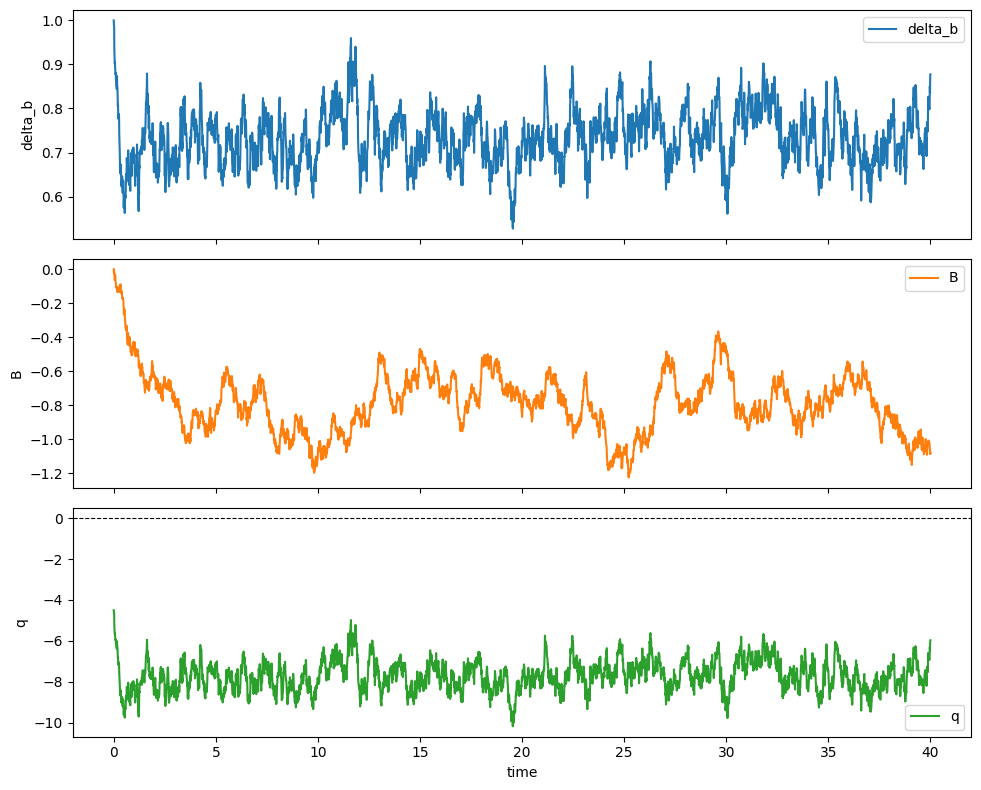

In [13]:
baseline = Melcher2025DOModel(parameter_contract='strict')
baseline.integrate(
    t_span=CONFIG['baseline_t_span'],
    y0=CONFIG['baseline_y0'],
    method='euler_maruyama',
    kwargs={'dt': CONFIG['dt'], 'random_seed': CONFIG['seed_baseline']},
)

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
ax[0].plot(baseline.time, baseline.state_variables['delta_b'], label='delta_b')
ax[0].legend()
ax[0].set_ylabel('delta_b')

ax[1].plot(baseline.time, baseline.state_variables['B'], label='B', color='tab:orange')
ax[1].legend()
ax[1].set_ylabel('B')

ax[2].plot(baseline.time, baseline.diagnostic_variables['q'], label='q', color='tab:green')
ax[2].axhline(0.0, color='black', linewidth=0.8, linestyle='--')
ax[2].legend()
ax[2].set_ylabel('q')
ax[2].set_xlabel('time')
plt.tight_layout()


## 2. Sensitivity to `alpha`, `gamma`, and `sigma`


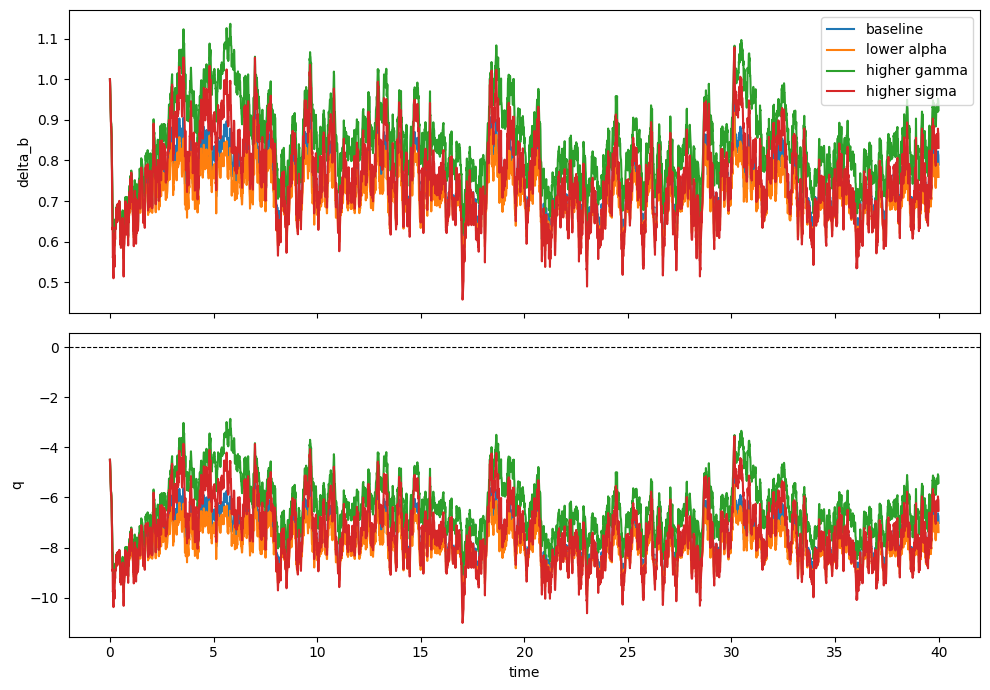

In [14]:
configs = [
    {'label': 'baseline', 'alpha': -0.6, 'gamma': 1.2, 'sigma': 0.2},
    {'label': 'lower alpha', 'alpha': -0.8, 'gamma': 1.2, 'sigma': 0.2},
    {'label': 'higher gamma', 'alpha': -0.6, 'gamma': 1.6, 'sigma': 0.2},
    {'label': 'higher sigma', 'alpha': -0.6, 'gamma': 1.2, 'sigma': 0.3},
]

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for cfg in configs:
    m = Melcher2025DOModel(
        parameter_contract='strict',
        alpha=cfg['alpha'],
        gamma=cfg['gamma'],
        sigma=cfg['sigma'],
    )
    m.integrate(
        t_span=CONFIG['baseline_t_span'],
        y0=CONFIG['baseline_y0'],
        method='euler_maruyama',
        kwargs={'dt': CONFIG['dt'], 'random_seed': CONFIG['seed_sensitivity']},
    )
    ax[0].plot(m.time, m.state_variables['delta_b'], label=cfg['label'])
    ax[1].plot(m.time, m.diagnostic_variables['q'], label=cfg['label'])

ax[0].set_ylabel('delta_b')
ax[0].legend(loc='upper right')
ax[1].set_ylabel('q')
ax[1].set_xlabel('time')
ax[1].axhline(0.0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()


## 3. Optional time-varying control parameters (`alpha(t)`, `gamma(t)` )


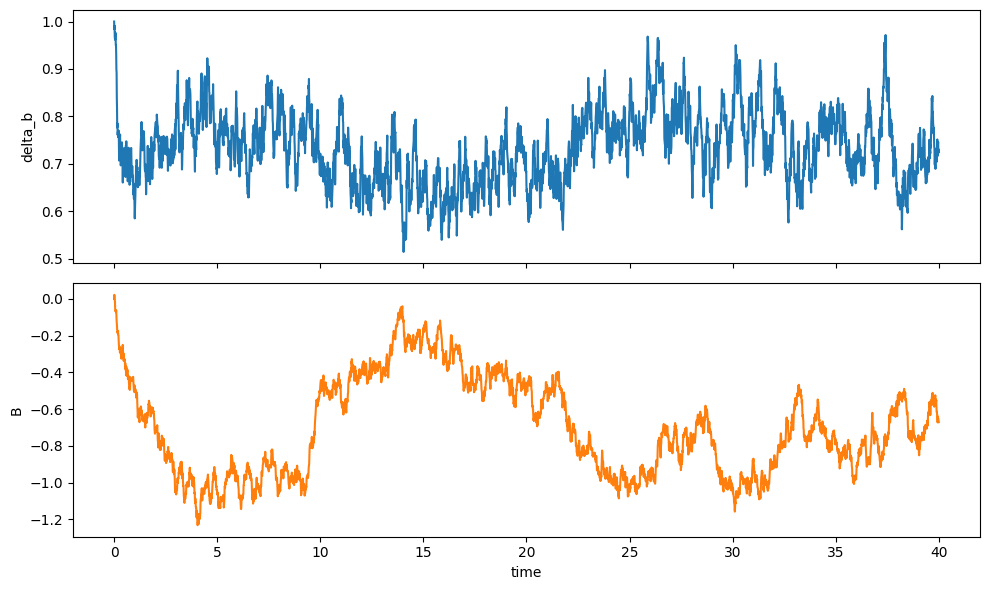

In [15]:
alpha_t = lambda t: -0.7 + 0.15 * np.sin(2 * np.pi * t / 20.0)
gamma_t = lambda t: 1.2 + 0.2 * np.cos(2 * np.pi * t / 30.0)

tv = Melcher2025DOModel(parameter_contract='strict', alpha=alpha_t, gamma=gamma_t, sigma=0.2)
tv.integrate(
    t_span=CONFIG['baseline_t_span'],
    y0=CONFIG['baseline_y0'],
    method='euler_maruyama',
    kwargs={'dt': CONFIG['dt'], 'random_seed': CONFIG['seed_timevarying']},
)

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(tv.time, tv.state_variables['delta_b'], color='tab:blue')
ax[0].set_ylabel('delta_b')
ax[1].plot(tv.time, tv.state_variables['B'], color='tab:orange')
ax[1].set_ylabel('B')
ax[1].set_xlabel('time')
plt.tight_layout()


## 4. Deterministic seed checks for `euler_maruyama`


In [16]:
kwargs_same_seed = {'dt': CONFIG['dt'], 'random_seed': CONFIG['seed_repro']}
kwargs_diff_seed = {'dt': CONFIG['dt'], 'random_seed': CONFIG['seed_repro_alt']}

a = Melcher2025DOModel(parameter_contract='strict')
b = Melcher2025DOModel(parameter_contract='strict')
c = Melcher2025DOModel(parameter_contract='strict')

a.integrate(t_span=CONFIG['baseline_t_span'], y0=CONFIG['baseline_y0'], method='euler_maruyama', kwargs=kwargs_same_seed)
b.integrate(t_span=CONFIG['baseline_t_span'], y0=CONFIG['baseline_y0'], method='euler_maruyama', kwargs=kwargs_same_seed)
c.integrate(t_span=CONFIG['baseline_t_span'], y0=CONFIG['baseline_y0'], method='euler_maruyama', kwargs=kwargs_diff_seed)

same_seed_match = np.allclose(a.state_variables['delta_b'], b.state_variables['delta_b'])
diff_seed_differs = not np.allclose(a.state_variables['delta_b'], c.state_variables['delta_b'])

print(f"Same seed reproducible: {same_seed_match}")
print(f"Different seeds differ: {diff_seed_differs}")

assert same_seed_match
assert diff_seed_differs


Same seed reproducible: True
Different seeds differ: True


## 5. Optional validation helpers against paper figure-code artifacts

`stadial/interstadial`, `E(t)`, and `P(t)` helpers are intentionally notebook-local (not model API).
The paper artifact comparison runs only if required files are found.


In [17]:
def _resolve_paper_root(configured_root=None):
    if configured_root is not None:
        forced = Path(configured_root)
        return forced if forced.exists() else None

    candidates = [
        Path('reference_papers/DO_events/2023_paper_Melcher_Halkjaer-main'),
        Path('../reference_papers/DO_events/2023_paper_Melcher_Halkjaer-main'),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None

paper_root = _resolve_paper_root(CONFIG.get('paper_root', None))
if paper_root is None:
    PAPER_ARTIFACTS_AVAILABLE = False
    data_dir = None
    print('Paper artifact directory not found. Skipping paper-data comparison section.')
else:
    data_dir = paper_root / 'Data'
    required = [
        paper_root / 'Data_for_f06.py',
        data_dir / 'NGRIP_lohman_E_P.npy',
        data_dir / 'lots_of_points_domain.npy',
        data_dir / 'lots_of_points_results.npy',
    ]
    missing = [str(p) for p in required if not p.exists()]
    PAPER_ARTIFACTS_AVAILABLE = len(missing) == 0

    if PAPER_ARTIFACTS_AVAILABLE:
        print(f'Paper artifacts found at: {paper_root.resolve()}')
    else:
        print('Paper artifact root found but required files are missing:')
        for m in missing:
            print(f'  - {m}')
        print('Proceeding without paper-data comparison outputs.')

paper_baseline = CONFIG['paper_baseline'].copy()
paper_baseline


Paper artifacts found at: /Users/jlanders/PycharmProjects/PaleoBeasts/reference_papers/DO_events/2023_paper_Melcher_Halkjaer-main


{'q0': -9.0, 'q1': 12.0, 'b0': 1, 'tau': 0.902}

In [18]:
def _as_time_x_ensemble(values):
    arr = np.asarray(values, dtype=float)
    squeeze = False
    if arr.ndim == 1:
        arr = arr[:, None]
        squeeze = True
    elif arr.ndim != 2:
        raise ValueError('Input must be 1D or 2D with shape (time, ensemble).')
    return arr, squeeze


def classify_stadial_interstadial(delta_b, low=1.0, high=1.4):
    """Hysteretic classifier. Enter stadial below `low`, exit above `high`."""
    if not (low < high):
        raise ValueError('Expected low < high for hysteresis thresholds.')

    arr, squeeze = _as_time_x_ensemble(delta_b)
    n_time, n_ens = arr.shape
    state = np.zeros(n_ens, dtype=float)
    out = np.zeros_like(arr, dtype=float)

    for i in range(n_time):
        state = np.where(arr[i] < low, 1.0, state)
        state = np.where(arr[i] > high, 0.0, state)
        out[i] = state

    return out[:, 0] if squeeze else out


def compute_p(is_stadial, window=1000):
    arr, squeeze = _as_time_x_ensemble(is_stadial)
    window = int(window)
    if window < 1:
        raise ValueError('window must be >= 1')
    if window > arr.shape[0]:
        raise ValueError('window must be <= number of time points')

    kernel = np.ones(window, dtype=float) / float(window)
    out = np.apply_along_axis(lambda x: np.convolve(x, kernel, mode='valid'), 0, arr)
    return out[:, 0] if squeeze else out


def compute_e(is_stadial, window=1000):
    arr, squeeze = _as_time_x_ensemble(is_stadial)
    window = int(window)
    if window < 1:
        raise ValueError('window must be >= 1')

    # Onset event: transition from non-stadial to stadial.
    onset = (np.diff(arr, axis=0) > 0).astype(float)

    if window > onset.shape[0]:
        raise ValueError('window must be <= number of transition samples (n_time - 1)')

    kernel = np.ones(window, dtype=float)
    out = np.apply_along_axis(lambda x: np.convolve(x, kernel, mode='valid'), 0, onset)
    return out[:, 0] if squeeze else out


In [19]:
# Helper sanity checks
const_stadial_series = np.full(1500, 0.5, dtype=float)
const_stadial_state = classify_stadial_interstadial(const_stadial_series)
P_const_stadial = compute_p(const_stadial_state, window=1000)
E_const_stadial = compute_e(const_stadial_state, window=1000)

assert np.allclose(P_const_stadial, 1.0)
assert np.allclose(E_const_stadial, 0.0)

const_interstadial_series = np.full(1500, 1.6, dtype=float)
const_interstadial_state = classify_stadial_interstadial(const_interstadial_series)
P_const_interstadial = compute_p(const_interstadial_state, window=1000)
E_const_interstadial = compute_e(const_interstadial_state, window=1000)

assert np.allclose(P_const_interstadial, 0.0)
assert np.allclose(E_const_interstadial, 0.0)

toy_state = np.array([0, 0, 1, 1, 0, 1, 1, 0], dtype=float)
E_toy = compute_e(toy_state, window=1)

# Two onsets: indices 2 and 5 in the original series.
assert int(np.sum(E_toy)) == 2
print('Helper sanity checks passed.')


Helper sanity checks passed.


Model ensemble summary (this notebook run)
E_mean=0.0005, P_mean=1.0000
Nearest precomputed sweep point from paper repo
sigma=0.202, gamma=1.192, alpha=-0.660
E_ref=0.0005, P_ref=1.0000


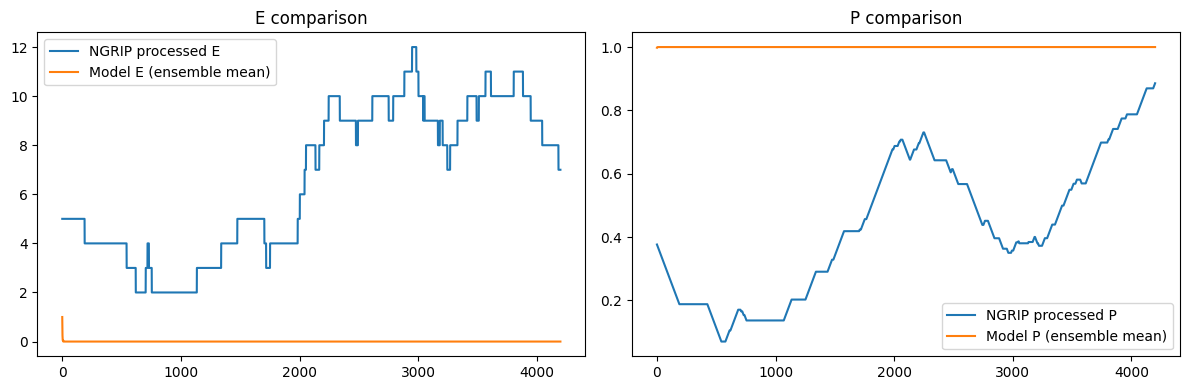

In [20]:
if not PAPER_ARTIFACTS_AVAILABLE:
    print('Skipping optional paper-data comparison. Core model demo sections above are still valid.')
else:
    ensemble = []
    for seed in range(int(CONFIG['ensemble_n'])):
        m = Melcher2025DOModel(
            parameter_contract='strict',
            q0=paper_baseline['q0'],
            q1=paper_baseline['q1'],
            b0=paper_baseline['b0'],
            tau=paper_baseline['tau'],
            alpha=-0.6,
            gamma=1.2,
            sigma=0.2,
        )
        m.integrate(
            t_span=CONFIG['ensemble_t_span'],
            y0=CONFIG['baseline_y0'],
            method='euler_maruyama',
            kwargs={'dt': CONFIG['ensemble_dt'], 'random_seed': seed},
        )
        ensemble.append(m.state_variables['delta_b'])

    delta_b_ens = np.stack(ensemble, axis=1)
    is_stadial = classify_stadial_interstadial(delta_b_ens, low=1.0, high=1.4)
    E_sim = compute_e(is_stadial, window=CONFIG['window'])
    P_sim = compute_p(is_stadial, window=CONFIG['window'])

    line_lohman = np.load(data_dir / 'NGRIP_lohman_E_P.npy')
    E_data = line_lohman[1][::-1][:84000][::20]
    P_data = line_lohman[3][::-1][:84000][::20]

    domain = np.load(data_dir / 'lots_of_points_domain.npy')
    results = np.load(data_dir / 'lots_of_points_results.npy')

    target = np.array([0.2, 1.2, -0.6])
    idx = np.argmin(np.sum((domain - target) ** 2, axis=1))
    E_ref, P_ref = results[idx, 0], results[idx, 1]

    print('Model ensemble summary (this notebook run)')
    print(f'E_mean={E_sim.mean():.4f}, P_mean={P_sim.mean():.4f}')
    print('Nearest precomputed sweep point from paper repo')
    print(f'sigma={domain[idx,0]:.3f}, gamma={domain[idx,1]:.3f}, alpha={domain[idx,2]:.3f}')
    print(f'E_ref={E_ref:.4f}, P_ref={P_ref:.4f}')

    n = min(len(E_data), E_sim.shape[0])
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(E_data[:n], label='NGRIP processed E', lw=1.5)
    ax[0].plot(E_sim[:n].mean(axis=1), label='Model E (ensemble mean)', lw=1.5)
    ax[0].set_title('E comparison')
    ax[0].legend()

    ax[1].plot(P_data[:n], label='NGRIP processed P', lw=1.5)
    ax[1].plot(P_sim[:n].mean(axis=1), label='Model P (ensemble mean)', lw=1.5)
    ax[1].set_title('P comparison')
    ax[1].legend()
    plt.tight_layout()


## 6. Transition highlighting on baseline time series

Onset transitions (`0 -> 1`) and exit transitions (`1 -> 0`) are highlighted using the notebook-local hysteresis classifier.


Onset transitions detected: 1
Exit transitions detected: 0


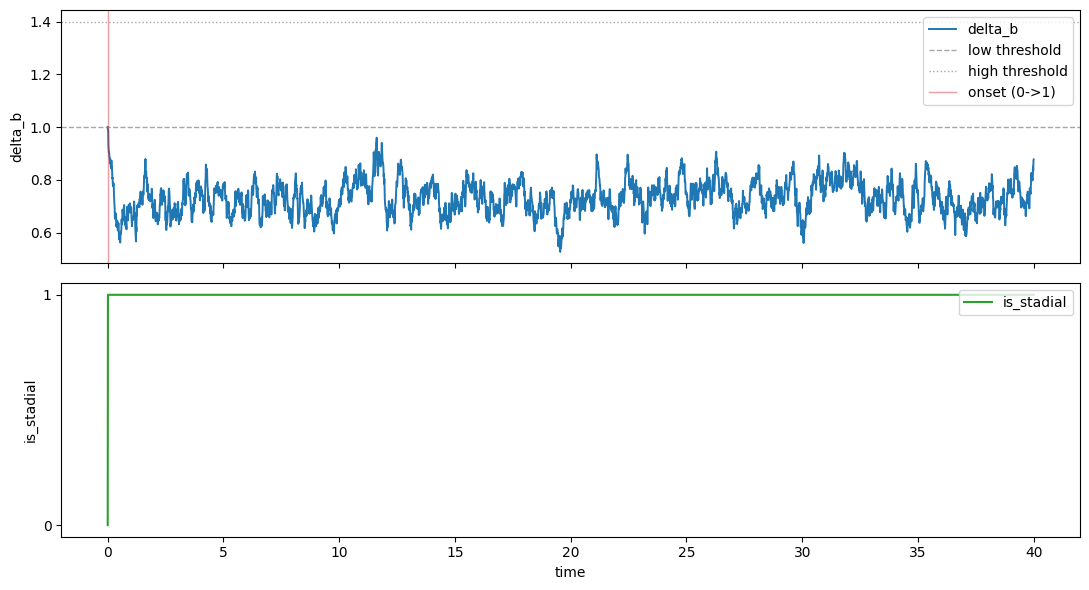

In [21]:
baseline_state = classify_stadial_interstadial(
    baseline.state_variables['delta_b'], low=1.0, high=1.4
)
transitions = np.diff(baseline_state)
onset_idx = np.where(transitions > 0)[0] + 1
exit_idx = np.where(transitions < 0)[0] + 1

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax[0].plot(baseline.time, baseline.state_variables['delta_b'], color='tab:blue', lw=1.4, label='delta_b')
ax[0].axhline(1.0, color='gray', lw=1.0, ls='--', alpha=0.7, label='low threshold')
ax[0].axhline(1.4, color='gray', lw=1.0, ls=':', alpha=0.7, label='high threshold')

for i, t_idx in enumerate(onset_idx):
    ax[0].axvline(
        baseline.time[t_idx],
        color='tab:red',
        alpha=0.45,
        lw=1.0,
        label='onset (0->1)' if i == 0 else None,
    )
for i, t_idx in enumerate(exit_idx):
    ax[0].axvline(
        baseline.time[t_idx],
        color='tab:purple',
        alpha=0.45,
        lw=1.0,
        label='exit (1->0)' if i == 0 else None,
    )

ax[0].set_ylabel('delta_b')
ax[0].legend(loc='upper right')

ax[1].plot(baseline.time, baseline_state, color='tab:green', lw=1.5, label='is_stadial')
ax[1].set_ylabel('is_stadial')
ax[1].set_xlabel('time')
ax[1].set_yticks([0, 1])
ax[1].legend(loc='upper right')

print(f'Onset transitions detected: {len(onset_idx)}')
print(f'Exit transitions detected: {len(exit_idx)}')

plt.tight_layout()
